# Relatividad y Gravitación
## Prof. Jorge I. Zuluaga

### Cuaderno de Clase: Geodésicas en la Métrica de Newton

## Paquetes requeridos

In [9]:
!pip install -Uq einsteinpy


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [1]:
import einsteinpy.symbolic as es
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pymcel as pc
from scipy.integrate import solve_ivp
import spiceypy as spy

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


## Ecuaciones de la geodésica

La métrica de Newton es:

$$
\mathrm{d}s^2 = \left(1-\frac{2GM}{c^2 r}\right) c^2 \mathrm{d}t^2 - \mathrm{d}x^2 - \mathrm{d}y^2 - \mathrm{d}z^2
$$

Calculamos los símbolos de Christoffel:

In [15]:
G, M, c, T, x, y, z = sp.symbols('G M c T x y z')

r = sp.sqrt(x**2 + y**2 + z**2)

gmat = np.diag([1-2*G*M/(c**2*r), -1, -1, -1])
coordenadas = T, x, y, z
gmet = es.MetricTensor(gmat, coordenadas)
Gab = es.ChristoffelSymbols.from_metric(gmet)
Gab.tensor()

[[[0, G*M*x/((-2*G*M + c**2*sqrt(x**2 + y**2 + z**2))*(x**2 + y**2 + z**2)), G*M*y/((-2*G*M + c**2*sqrt(x**2 + y**2 + z**2))*(x**2 + y**2 + z**2)), G*M*z/((-2*G*M + c**2*sqrt(x**2 + y**2 + z**2))*(x**2 + y**2 + z**2))], [G*M*x/((-2*G*M + c**2*sqrt(x**2 + y**2 + z**2))*(x**2 + y**2 + z**2)), 0, 0, 0], [G*M*y/((-2*G*M + c**2*sqrt(x**2 + y**2 + z**2))*(x**2 + y**2 + z**2)), 0, 0, 0], [G*M*z/((-2*G*M + c**2*sqrt(x**2 + y**2 + z**2))*(x**2 + y**2 + z**2)), 0, 0, 0]], [[G*M*x/(c**2*(x**2 + y**2 + z**2)**(3/2)), 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]], [[G*M*y/(c**2*(x**2 + y**2 + z**2)**(3/2)), 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]], [[G*M*z/(c**2*(x**2 + y**2 + z**2)**(3/2)), 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]]]

Ecuaciones de la geodésica:

In [16]:
xpp = sp.symbols(r'\ddot{T} \ddot{x} \ddot{y} \ddot{z}')
xp = sp.symbols(r'\dot{T} \dot{x} \dot{y} \dot{z}')

for sigma in range(4):
    ecuacion = 0
    for mu in range(4):
        for nu in range(4):
            ecuacion += -Gab[sigma, mu, nu] * xp[mu] * xp[nu]

    ecuacion = sp.Eq(xpp[sigma],ecuacion)
    display(ecuacion)

Eq(\ddot{T}, -2*G*M*\dot{T}*\dot{x}*x/((-2*G*M + c**2*sqrt(x**2 + y**2 + z**2))*(x**2 + y**2 + z**2)) - 2*G*M*\dot{T}*\dot{y}*y/((-2*G*M + c**2*sqrt(x**2 + y**2 + z**2))*(x**2 + y**2 + z**2)) - 2*G*M*\dot{T}*\dot{z}*z/((-2*G*M + c**2*sqrt(x**2 + y**2 + z**2))*(x**2 + y**2 + z**2)))

Eq(\ddot{x}, -G*M*\dot{T}**2*x/(c**2*(x**2 + y**2 + z**2)**(3/2)))

Eq(\ddot{y}, -G*M*\dot{T}**2*y/(c**2*(x**2 + y**2 + z**2)**(3/2)))

Eq(\ddot{z}, -G*M*\dot{T}**2*z/(c**2*(x**2 + y**2 + z**2)**(3/2)))

In [17]:
def edg_newton(tau, Ys, G, M, c):
    T, x, y, z, Ut, Ux, Uy, Uz = Ys

    r = np.sqrt(x**2 + y**2 + z**2)

    # Derivadas de las coordenadas
    dT_dtau = Ut
    dx_dtau = Ux
    dy_dtau = Uy
    dz_dtau = Uz

    # Factor común de Gamma^0_{0i}
    denom = (c**2 * r - 2 * G * M) * r**2

    # Derivadas de las 4-velocidades (a partir de xpp^sigma = -Gamma^sigma_{mu nu} xp^mu xp^nu)
    dUt_dtau = -2 * G * M * Ut * (x * Ux + y * Uy + z * Uz) / denom
    dUx_dtau = -(G * M * x / (c**2 * r**3)) * Ut**2
    dUy_dtau = -(G * M * y / (c**2 * r**3)) * Ut**2
    dUz_dtau = -(G * M * z / (c**2 * r**3)) * Ut**2

    return [dT_dtau, dx_dtau, dy_dtau, dz_dtau,
            dUt_dtau, dUx_dtau, dUy_dtau, dUz_dtau]

Probamos que la rutina funciona:

In [19]:
edg_newton(1, [1, 1, 1, 1, 1, 1, 1, 1], 2, 2, 2)

[1,
 1,
 1,
 1,
 np.float64(7.464101615137753),
 np.float64(-0.1924500897298753),
 np.float64(-0.1924500897298753),
 np.float64(-0.1924500897298753)]

## Solución a las ecuaciones geodésica

Como aparece en el panorama la constante de gravitación universal $G$ ahora las unidades se escogen no solo para que sean relativistas $c=1$ sino también para que sean unidades canónicas $G=1$. Las ecuaciones de las unidades son:

$$
c = \frac{U_L}{U_T}\\
G = \frac{U_L^3}{U_M U_T^2}\\
$$

Despejando $U_T$ de la primera ecuación y reemplazandola en la segunda queda:

$$
G = \frac{c^2 U_L}{U_M}\\
$$

Si fijamos la unidad de masa, la unidad de longitud queda:

$$
U_L = \frac{G U_M}{c^2}\\
$$

Vamos a simular el movimiento de un cuerpo alrededor de un agujero negro con la masa del Sol entonces escogemos como unidad de masa la masa solar:

In [24]:
# Unidades relativistas: c = 1, c = UL / UT
UM = pc.constantes.M_sun # en kg
UL = pc.constantes.G * UM / pc.constantes.c**2 # en metros
UT = UL / pc.constantes.c

# Unidades derivadas
UV = UL / UT
UA = UL / UT**2

# Constantes
G = 1
C = 1

UL, UT, UV, UA, C

(np.float64(1476.6250380501249),
 np.float64(4.9254909476412675e-06),
 np.float64(299792458.0),
 np.float64(60865497711160.234),
 1)

Vemos que la unidad de longitud es 1476 m = 1.5 km, lo que nos da una idea de a qué distancia poner el cuerpo para su trayectoria.

Condiciones iniciales:

Vamos a colocar el cuerpo a 5000 km del centro y moviéndose con una velocidad igual a la velocidad circular $v=\sqrt{\mu/r}$:

In [240]:
M = 1

t0 = 0
x0 = 5000e3 / UL # 5000 km
y0 = 0 
z0 = 0 
r0 = np.sqrt(x0**2 + y0**2 + z0**2)

vx0 = 0  
vy0 = np.sqrt(G*M/r0) # Como G, M, r0 ya están en unidades relativistas no necesitan conversión
vz0 = 0 

Condiciones iniciales en el espacio-tiempo:

In [241]:
T0 = C*t0
# Las posiciones son las mismas
g00 = 1 - 2*G*M/ (C**2 * r0)
g11 = g22 = g33 = -1

Ut0 = 1 / np.sqrt(g00 + g11*vx0**2 + g22*vy0**2 + g33*vz0**2)
Ux0 = vx0 * Ut0 / C
Uy0 = vy0 * Ut0 / C
Uz0 = vz0 * Ut0 / C

Tiempos y condiciones iniciales:

¿Por cuánto tiempo integrar? Vamos a usar la tercera ley de Kepler: $n^2 a^3 = \mu$:

In [242]:
T = 2*np.pi * np.sqrt(r0**3 / (G*M))

taus = np.linspace(0, 0.98*T, 1000)
Ys0 = [T0, x0, y0, z0, Ut0, Ux0, Uy0, Uz0]
solucion = solve_ivp(edg_newton, (taus[0], taus[-1]), Ys0, t_eval=taus, args=(G, M, C), method='Radau')

Extraemos la solución y la ponemos en unidades del sistema internacional:

In [235]:
ts = solucion.y[0] / C * UT
xs = solucion.y[1] * UL
ys = solucion.y[2] * UL
zs = solucion.y[3] * UL

Graficamos:

(np.float64(-5498896.224390645),
 np.float64(5499947.439256697),
 np.float64(-5498710.25118954),
 np.float64(5500519.961525939))

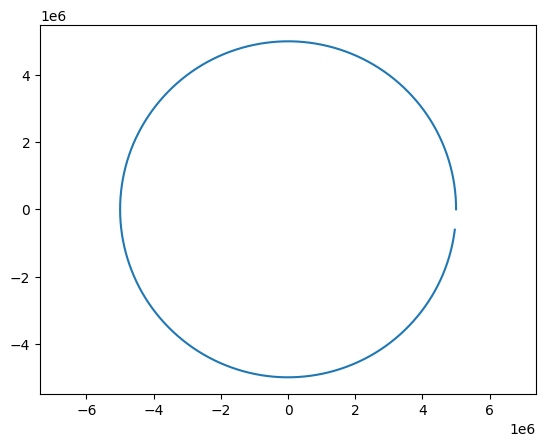

In [236]:
plt.plot(xs, ys)
plt.axis('equal')

Comparemos con lo que esperamos según la mecánica celeste:

In [237]:
x0, y0, z0, vx0, vy0, vz0

(np.float64(3386.0999720026907), 0, 0, 0, np.float64(0.017185022770134027), 0)

In [238]:
Xs = np.zeros((len(ts), 6))
for i, t in enumerate(ts/UT):
    Xs[i] = spy.prop2b(G*M, [x0, y0, z0, vx0, vy0, vz0], t)

Comparemos:


(np.float64(-5499978.134451515),
 np.float64(5499998.958783406),
 np.float64(-5500023.673596006),
 np.float64(5500582.505450057))

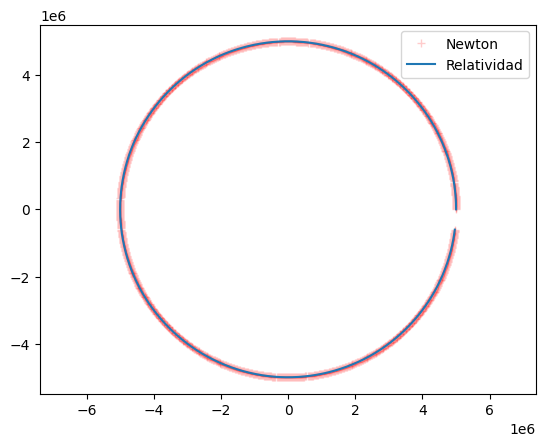

In [239]:
plt.plot(Xs[:, 0]*UL, Xs[:, 1]*UL, 'r+', label='Newton', alpha=0.2)
plt.plot(xs, ys, label='Relatividad')
plt.legend()
plt.axis('equal')

Que coincide exactamente.